<>:184: SyntaxWarning: invalid escape sequence '\s'
<>:184: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_37190/4070275987.py:184: SyntaxWarning: invalid escape sequence '\s'
  ax2.set_ylabel("Residui ($\sigma$)")



--- RISULTATI FIT ---
e = 171023.610 ± 102634034304.334 V
Ramp = 2956.9 ± 265.2 Ohm
Re = 32265711.5 ± 19363176537713.1 Ohm

chi2 / ndof = 331.84 / 12 = 27.65


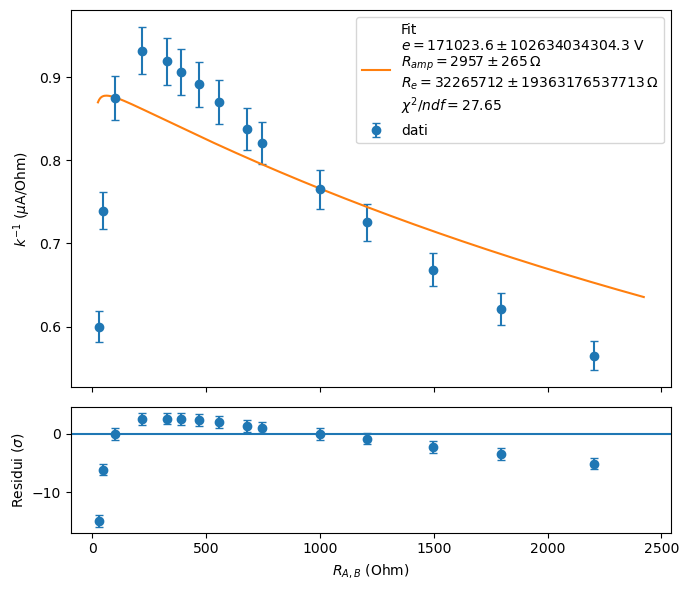

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

#   --- K^-1 ---
R_AB = np.array([            27.14,
            46.92,
            99.93,
            219.67,
            329.51,
            389.52,
            469.39,
            558.31,
            680.05,
            747.08,
            1001.9,
            1205.9,
            1496.8,
            1797.3,
            2202.7,])

k_uA = np.array([        1.666666667,
        1.352569883,
        1.142857143,
        1.072961373,
        1.088139282,
        1.102941176,
        1.121914734,
        1.148545176,
        1.19379228,
        1.218026797,
        1.307189542,
        1.378676471,
        1.49551346,
        1.610305958,
        1.769911504,])

k_inv_uA = 1/k_uA

s_k_uA = np.array([        0.05064926371,
        0.0410539499,
        0.03466526908,
        0.03253868943,
        0.03300037178,
        0.03345066952,
        0.03402796134,
        0.03483838342,
        0.03621579007,
        0.03695376941,
        0.03967037977,
        0.04185018909,
        0.04541641649,
        0.04892488779,
        0.05381131626,])

s_k_inv_uA = s_k_uA / (k_uA**2)

Rn = np.array([        0.6066759525,
        0.6353838708,
        0.6338619274,
        0.6489028104,
        0.6472760176,
        0.6538285166,
        0.6873864719,
        0.629388503,
        0.6304407535,
        0.6495452146,
        0.636113696,
        0.6343800499,
        0.6228179413,
        0.6271128335,
        0.6255812787,])

# -----------------------
# MODELLO TEORICO
# -----------------------

def model(X, e, Ramp, Re):
    R, Rn = X

    denom = (
        (R + 2*Ramp + Rn) *
        (R*Re + 2*R*Rn + Re*Rn)
    )

    return (e * R) / denom

# -----------------------
# FIT
# -----------------------

X_data = np.vstack((R_AB, Rn))

# stime iniziali (importante per stabilità!)
p0 = [10.0, 170.0, 0]  # e, Ramp, Re

popt, pcov = curve_fit(
    model,
    X_data,
    k_inv,
    sigma=s_k_inv,
    absolute_sigma=True,
    p0=p0,
    maxfev=10000
)

e, Ramp, Re = popt
se, sRamp, sRe = np.sqrt(np.diag(pcov))

print("\n--- RISULTATI FIT ---")
print(f"e = {e:.3f} ± {se:.3f} V")
print(f"Ramp = {Ramp:.1f} ± {sRamp:.1f} Ohm")
print(f"Re = {Re:.1f} ± {sRe:.1f} Ohm")

# -----------------------
# CHI QUADRO
# -----------------------

k_model = model((R_AB, Rn), e, Ramp, Re)

chi2 = np.sum(((k_inv - k_model)/s_k_inv)**2)
ndof = len(k_inv) - len(popt)

print(f"\nchi2 / ndof = {chi2:.2f} / {ndof} = {chi2/ndof:.2f}")

# -----------------------
# CURVA FIT
# -----------------------

x_fit = np.linspace(min(R_AB)*0.9, max(R_AB)*1.1, 500)
Rn_mean = np.mean(Rn)

y_fit_uA = model((x_fit, np.full_like(x_fit, Rn_mean)),
                 e, Ramp, Re) * 1e6

# valori modello sui punti
y_model_uA = model((R_AB, Rn), e, Ramp, Re) * 1e6

# residui
residuals = k_inv_uA - y_model_uA
res_norm = residuals / s_k_inv_uA

# -----------------------
# GRAFICO
# -----------------------

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(7,6),
    sharex=True,
    gridspec_kw={'height_ratios': [3, 1]}
)

# dati
ax1.errorbar(R_AB, k_inv_uA,
             yerr=s_k_inv_uA,
             fmt='o',
             capsize=3,
             label="dati")

# fit
ax1.plot(x_fit, y_fit_uA,
         label=(rf"Fit"
                "\n"
                rf"$e = {e:.1f} \pm {se:.1f}$ V"
                "\n"
                rf"$R_{{amp}} = {Ramp:.0f} \pm {sRamp:.0f}\,\Omega$"
                "\n"
                rf"$R_e = {Re:.0f} \pm {sRe:.0f}\,\Omega$"
                "\n"
                rf"$\chi^2 /ndf = {chi2/ndof:.2f}$"))

ax1.set_ylabel(r"$k^{-1}$ ($\mu$A/Ohm)")
ax1.legend()
ax1.grid(False)

# residui
ax2.errorbar(R_AB, res_norm,
             yerr=np.ones_like(res_norm),
             fmt='o',
             capsize=3)

ax2.axhline(0)
ax2.set_xlabel(r"$R_{A,B}$ (Ohm)")
ax2.set_ylabel("Residui ($\sigma$)")
ax2.grid(False)

plt.tight_layout()